# AstroSpectro · PHY-3500 — Notebook 01 : Analyse en Composantes Principales (ACP)

**Auteurs** : Alex, Justine  
**Cours** : PHY-3500 Physique numérique — Université Laval  
**Données** : LAMOST DR5 × Gaia DR3

---

## Objectifs

1. Appliquer la PCA sur les **features spectroscopiques engineerées** (71–196 descripteurs).
2. Appliquer la PCA sur les **spectres bruts** interpolés sur grille commune (~3900 pixels).
3. Analyser la **variance expliquée** et choisir le nombre de composantes.
4. Interpréter les **loadings** en termes de physique stellaire (raies spectrales).
5. Calculer les **corrélations** PC ↔ paramètres Gaia (T_eff, log g, [Fe/H]).
6. Valider la robustesse (contrôles, erreur de reconstruction).

## Lien avec PHY-3500

La PCA repose sur la **décomposition en valeurs propres** de la matrice de covariance,
thème central du cours (problèmes aux valeurs propres, section 3). La SVD utilisée
par sklearn est l'algorithme de référence (Golub & Reinsch 1970, NR chap. 11).

## 0 · Imports & configuration

In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Environnement projet (même pattern que 00_master_pipeline) ─────────────
# Le notebook est dans notebooks/dimred/ → src est à ../../src
sys.path.insert(0, str(Path("../..").resolve() / "src"))

from utils import setup_project_env, latest_file

paths = setup_project_env(verbose=True)

# ── Chemins ────────────────────────────────────────────────────────────────
# Trouve automatiquement le CSV de features le plus récent dans data/reports/
FEATURES_PATH = latest_file(paths["PROCESSED_DIR"], "features_*.csv")
CATALOG_PATH  = Path(paths["CATALOG_DIR"]) / "master_catalog_gaia.csv"

if FEATURES_PATH is None:
    raise FileNotFoundError(
        "Aucun fichier features_*.csv trouvé dans data/reports/\n"
        "→ Lancer d'abord 00_master_pipeline.ipynb pour générer les features."
    )

FEATURES_PATH = Path(FEATURES_PATH)
FIGURES_ROOT  = Path(paths["REPORTS_DIR"]) / "figures" / "phy3500"
FIGURES_DIR   = FIGURES_ROOT / FEATURES_PATH.stem
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nFeatures  : {FEATURES_PATH}")
print(f"Catalog   : {CATALOG_PATH}")
print(f"Figures   : {FIGURES_DIR}")

# ── Imports dimred ──────────────────────────────────────────────────────────
from dimred import DimRedDataLoader, PCAAnalyzer, DimRedVisualizer

# ── Logging & reproductibilité ─────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

[INFO] Project root detected: C:\Users\alexb\Documents\Projets\AstroSpectro
[INFO] 'src' directory added to sys.path.

Features  : C:\Users\alexb\Documents\Projets\AstroSpectro\data\processed\features_20260305T174836Z.csv
Catalog   : C:\Users\alexb\Documents\Projets\AstroSpectro\data\catalog\master_catalog_gaia.csv
Figures   : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z


## 1 · Chargement des données

In [2]:
loader = DimRedDataLoader(
    features_path=FEATURES_PATH,
    catalog_path=CATALOG_PATH,
    random_state=RANDOM_STATE,
)

X, y, meta = loader.load(
    mode="features",
    snr_min=10,            # SNR minimum bande r
    scale=True,            # StandardScaler (obligatoire pour PCA)
    class_balance=False,   # Pas d'équilibrage pour l'ACP exploratoire
)

feature_names = loader.get_feature_names()

print(f"\n{'='*55}")
print(f"Matrice X    : {X.shape}  (N spectres × D features)")
print(f"Classes y    : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Features     : {len(feature_names)}")
print(f"Params Gaia  : {list(meta.columns)}")

INFO | dimred.data_loader | Features chargées : features_20260305T174836Z.csv — 313 colonnes
INFO | dimred.data_loader | Catalog Gaia chargé : 99999 objets
INFO | dimred.data_loader | Merge features ∩ catalog : 99999 lignes
INFO | dimred.data_loader | Filtre SNR (snr_r >= 10.0) : 99999 → 53134 lignes
INFO | dimred.data_loader | 208 features sélectionnées pour la réduction de dimension
INFO | dimred.data_loader | Suppression NaN résiduel : 53134 → 42920 lignes
INFO | dimred.data_loader | Données prêtes : X=(42920, 208) | classes={'GALAXY': np.int64(54), 'QSO': np.int64(4), 'STAR': np.int64(42862)} | features=208



Matrice X    : (42920, 208)  (N spectres × D features)
Classes y    : {'GALAXY': np.int64(54), 'QSO': np.int64(4), 'STAR': np.int64(42862)}
Features     : 208
Params Gaia  : ['teff_gspphot', 'logg_gspphot', 'mh_gspphot', 'bp_rp', 'bp_g', 'g_rp', 'phot_g_mean_mag', 'distance_gspphot', 'pmra', 'pmdec', 'parallax', 'ruwe', 'ag_gspphot', 'ebpminrp_gspphot', 'phot_variable_flag', 'snr_u', 'snr_g', 'snr_r', 'snr_i', 'snr_z', 'class', 'subclass', 'ra', 'dec', 'redshift']


## 2 · Ajustement de la PCA

In [3]:
# Ajustement avec 50 composantes (exploration)
# sklearn utilise la SVD tronquée (LAPACK/ARPACK) — algorithme NR chap. 11
pca = PCAAnalyzer(n_components=50, random_state=RANDOM_STATE)
scores = pca.fit_transform(X, feature_names=feature_names)

print(f"Composantes retenues : {pca.sklearn_pca.n_components_}")
print(f"Variance totale expliquée : {pca.cumulative_variance[-1]*100:.2f}%")
print("\n--- Résumé variance (10 premières PCs) ---")
print(pca.variance_summary().head(10).to_string(index=False))

INFO | dimred.pca_analyzer | PCA ajustée : 50 composantes, 75.09% variance expliquée (cumulative)


Composantes retenues : 50
Variance totale expliquée : 75.09%

--- Résumé variance (10 premières PCs) ---
  PC  variance_individuelle  variance_cumulee  valeur_propre
 PC1               0.148556          0.148556      30.306088
 PC2               0.105432          0.253988      21.508688
 PC3               0.043429          0.297417       8.859779
 PC4               0.031946          0.329363       6.517065
 PC5               0.029294          0.358657       5.976151
 PC6               0.021799          0.380456       4.447092
 PC7               0.019827          0.400283       4.044833
 PC8               0.016277          0.416560       3.320614
 PC9               0.015718          0.432278       3.206509
PC10               0.014083          0.446361       2.872968


## 3 · Analyse de la variance expliquée

INFO | dimred.pca_analyzer | 95% variance → 51 composantes (sur 50)


IndexError: index 50 is out of bounds for axis 0 with size 50

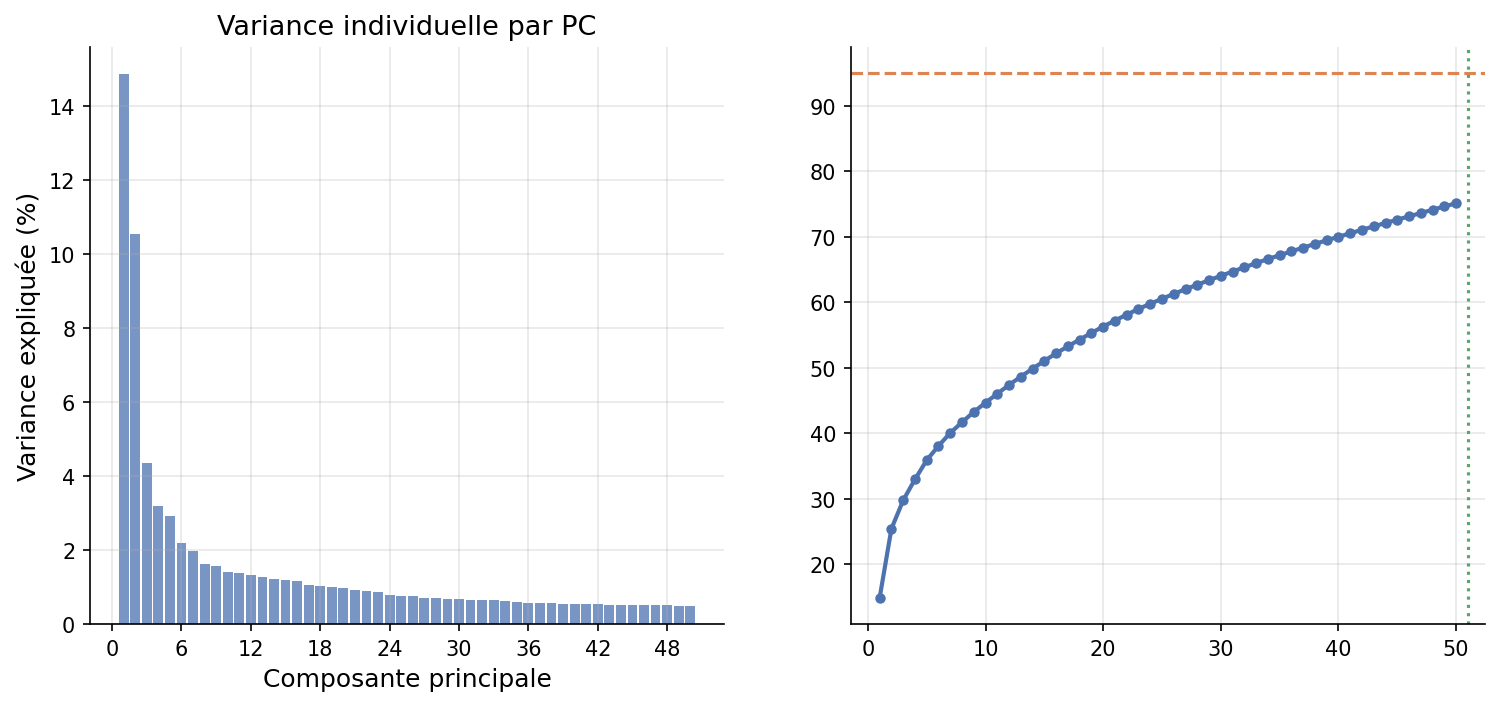

In [4]:
viz = DimRedVisualizer(figsize=(12, 5), dpi=150, output_dir=FIGURES_DIR)

fig, axes = viz.plot_variance_explained(
    pca,
    threshold=0.95,
    max_pcs=50,
    save_path=FIGURES_DIR / "pca_variance_explained.png",
)
plt.show()

print("\nSeuils de variance expliquée :")
for threshold in [0.80, 0.90, 0.95, 0.99]:
    n = pca.n_components_for_variance(threshold)
    print(f"  {threshold*100:.0f}% variance → {n} composantes")

## 4 · Loadings — Interprétation physique des axes

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_loadings_heatmap.png


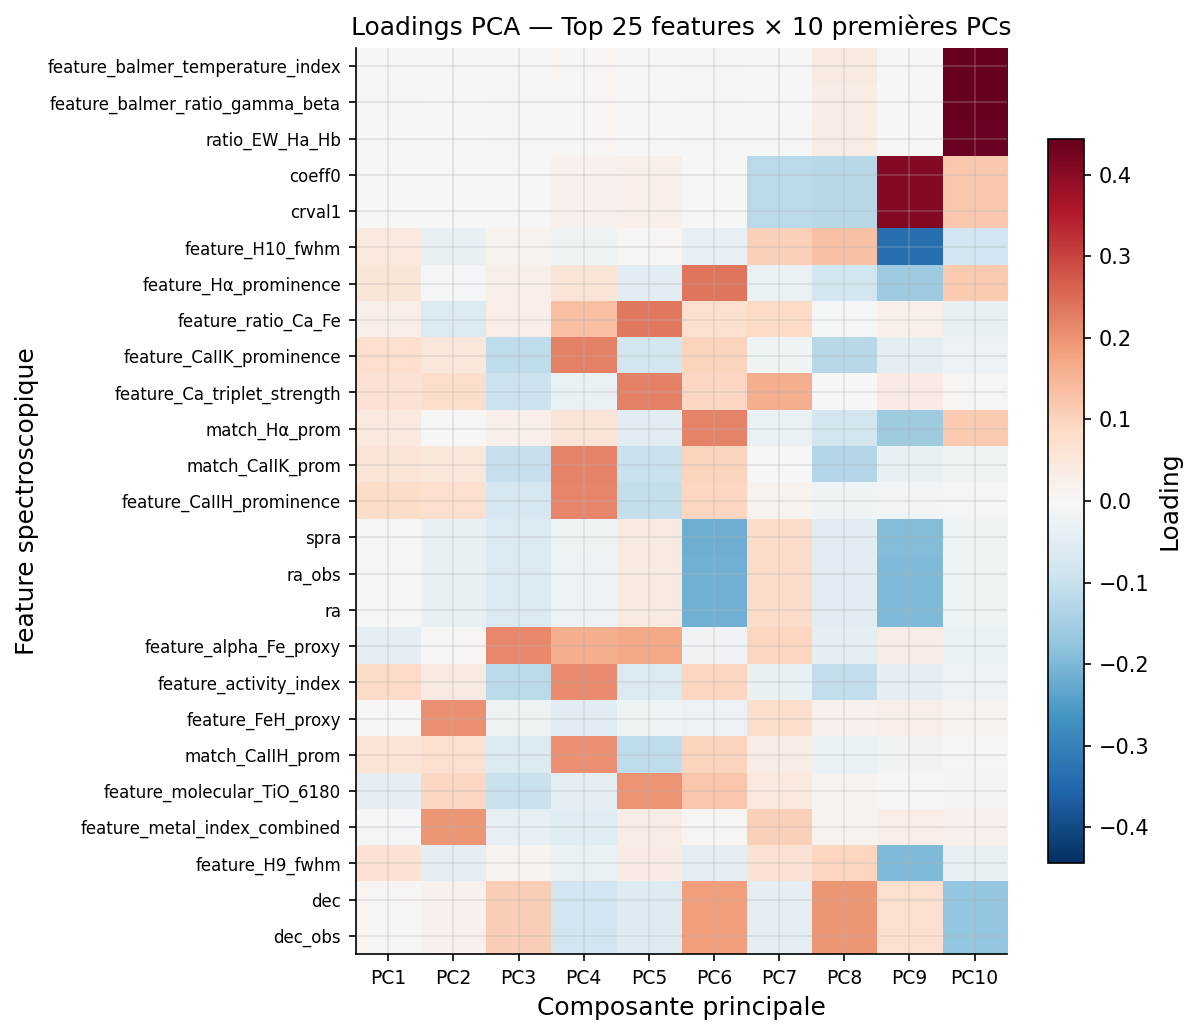

In [5]:
# Heatmap complète (features × PCs)
fig, ax = viz.plot_loadings_heatmap(
    pca, n_pcs=10, n_features=25,
    save_path=FIGURES_DIR / "pca_loadings_heatmap.png",
)
plt.show()

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_loadings_pc1.png


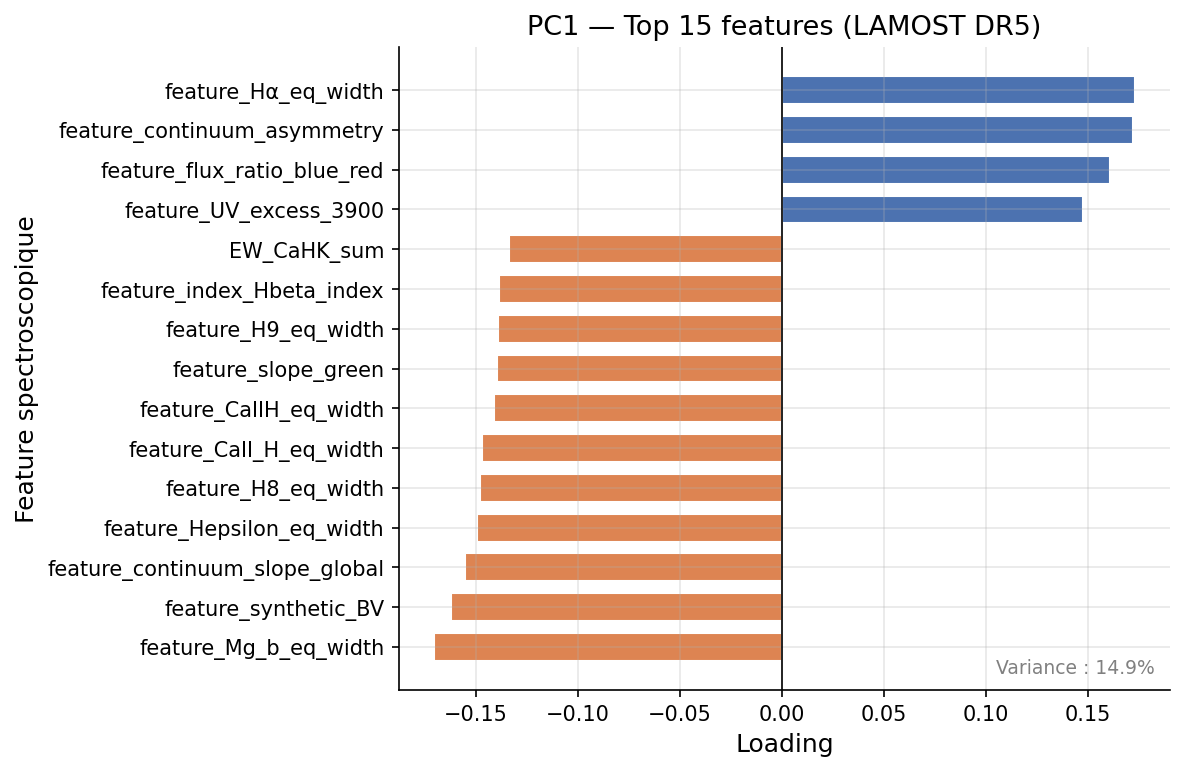

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_loadings_pc2.png


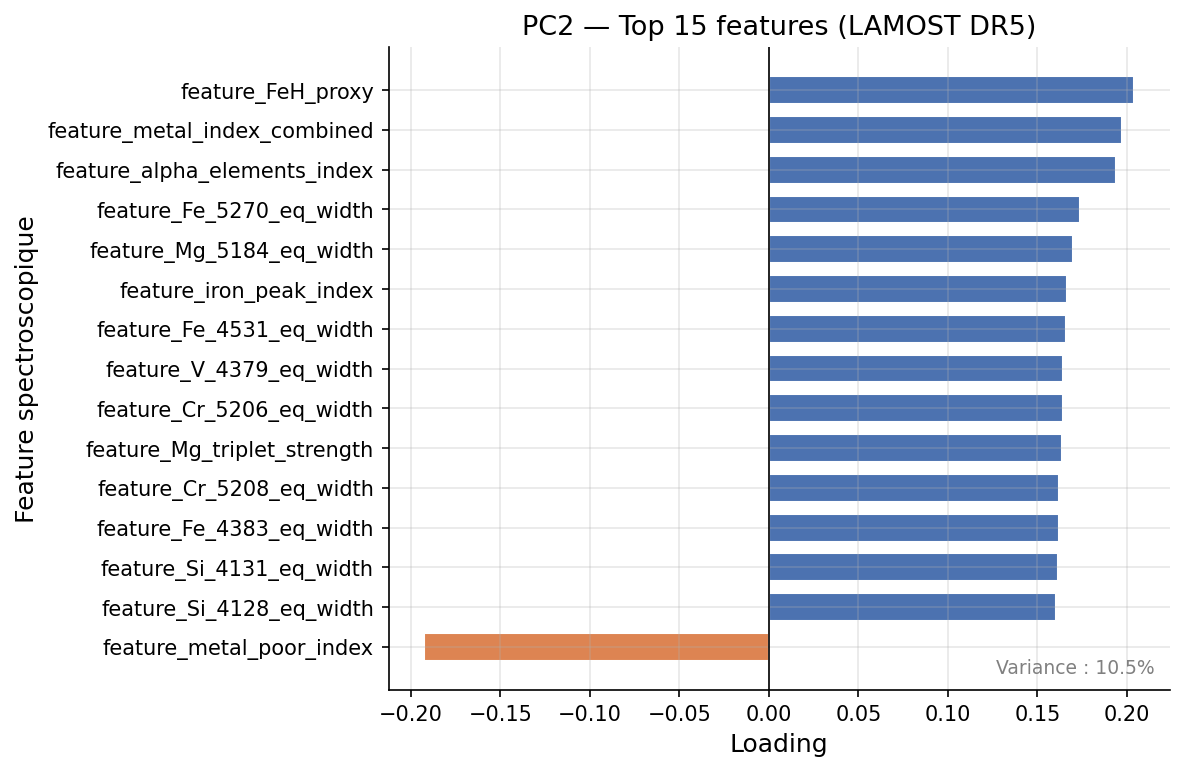


--- Top 10 features PC1 ---
                       feature   loading  abs_loading  PC
           feature_Hα_eq_width  0.172865     0.172865 PC1
   feature_continuum_asymmetry  0.171683     0.171683 PC1
         feature_Mg_b_eq_width -0.170330     0.170330 PC1
          feature_synthetic_BV -0.162220     0.162220 PC1
   feature_flux_ratio_blue_red  0.160631     0.160631 PC1
feature_continuum_slope_global -0.155273     0.155273 PC1
     feature_Hepsilon_eq_width -0.149469     0.149469 PC1
           feature_H8_eq_width -0.147916     0.147916 PC1
        feature_UV_excess_3900  0.147383     0.147383 PC1
       feature_CaII_H_eq_width -0.146882     0.146882 PC1

--- Top 10 features PC2 ---
                     feature   loading  abs_loading  PC
           feature_FeH_proxy  0.204162     0.204162 PC2
feature_metal_index_combined  0.197427     0.197427 PC2
feature_alpha_elements_index  0.193629     0.193629 PC2
    feature_metal_poor_index -0.192569     0.192569 PC2
    feature_Fe_5270_eq_w

In [6]:
# Barplot PC1 & PC2 — interprétation physique
fig, ax = viz.plot_loadings_bar(
    pca, pc_idx=0, n_top=15,
    save_path=FIGURES_DIR / "pca_loadings_pc1.png",
)
plt.show()

fig, ax = viz.plot_loadings_bar(
    pca, pc_idx=1, n_top=15,
    save_path=FIGURES_DIR / "pca_loadings_pc2.png",
)
plt.show()

print("\n--- Top 10 features PC1 ---")
print(pca.top_features_per_pc(pc_idx=0, n_top=10).to_string(index=False))
print("\n--- Top 10 features PC2 ---")
print(pca.top_features_per_pc(pc_idx=1, n_top=10).to_string(index=False))

## 5 · Corrélations PC ↔ paramètres physiques Gaia

Corrélations Spearman (PC × paramètres Gaia) :
      teff_gspphot  logg_gspphot  mh_gspphot  bp_rp   bp_g   g_rp  phot_g_mean_mag  distance_gspphot   pmra  pmdec  parallax   ruwe  ag_gspphot  ebpminrp_gspphot  snr_u  snr_g  snr_r  snr_i  snr_z     ra    dec  redshift
PC1          0.832        -0.157      -0.546 -0.765 -0.758 -0.748           -0.092             0.326 -0.042  0.097    -0.275 -0.074      -0.067            -0.063  0.607  0.349  0.068 -0.105 -0.174 -0.028  0.063     0.024
PC2          0.155         0.072      -0.075 -0.010 -0.014 -0.007            0.168             0.105  0.018  0.080    -0.098  0.026       0.210             0.212 -0.194 -0.329 -0.313 -0.238 -0.217 -0.138  0.068     0.025
PC3          0.234        -0.408       0.063  0.115  0.110  0.119           -0.403             0.261  0.016  0.179    -0.236  0.083       0.392             0.391  0.163  0.169  0.196  0.139  0.222 -0.159  0.253     0.029
PC4         -0.131         0.311      -0.166 -0.008 -0.012 -0.007    

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_correlation_heatmap.png


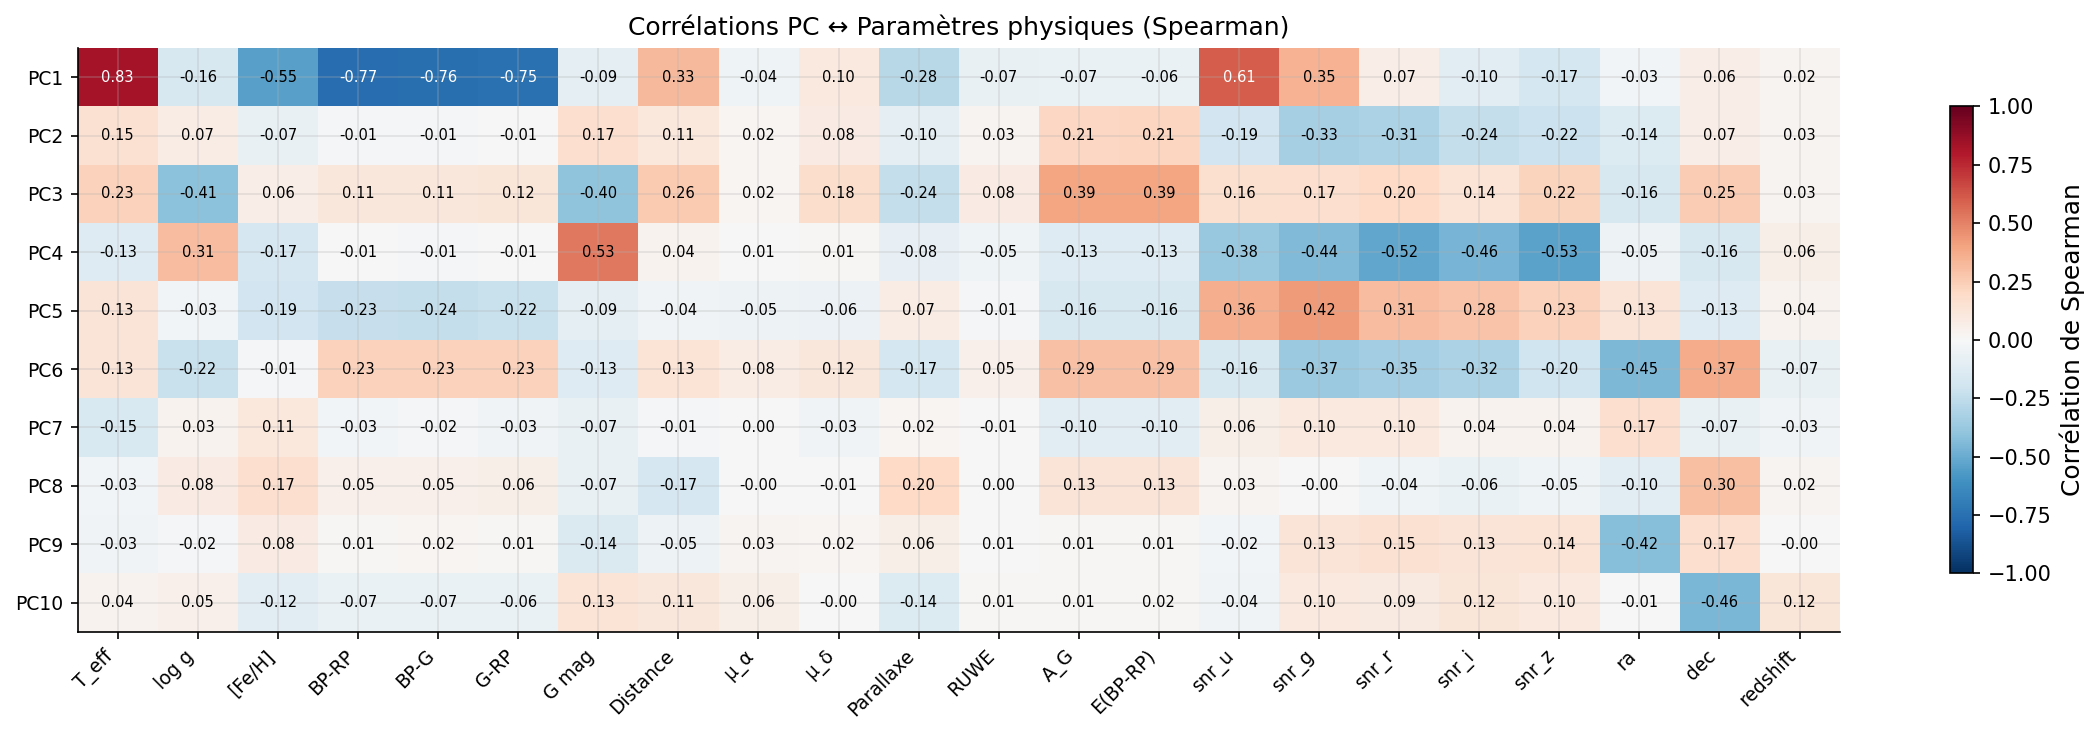

In [7]:
# Corrélations Spearman — robuste aux outliers et distributions non-normales
corr_df = pca.correlations_with_params(
    meta=meta,
    scores=scores,
    method="spearman",
    n_pcs=10,
)

print("Corrélations Spearman (PC × paramètres Gaia) :")
print(corr_df.round(3).to_string())

fig, ax = viz.plot_correlation_heatmap(
    corr_df,
    save_path=FIGURES_DIR / "pca_correlation_heatmap.png",
)
plt.show()

## 6 · Scores PCA — Scatter plots

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_scores_classes.png


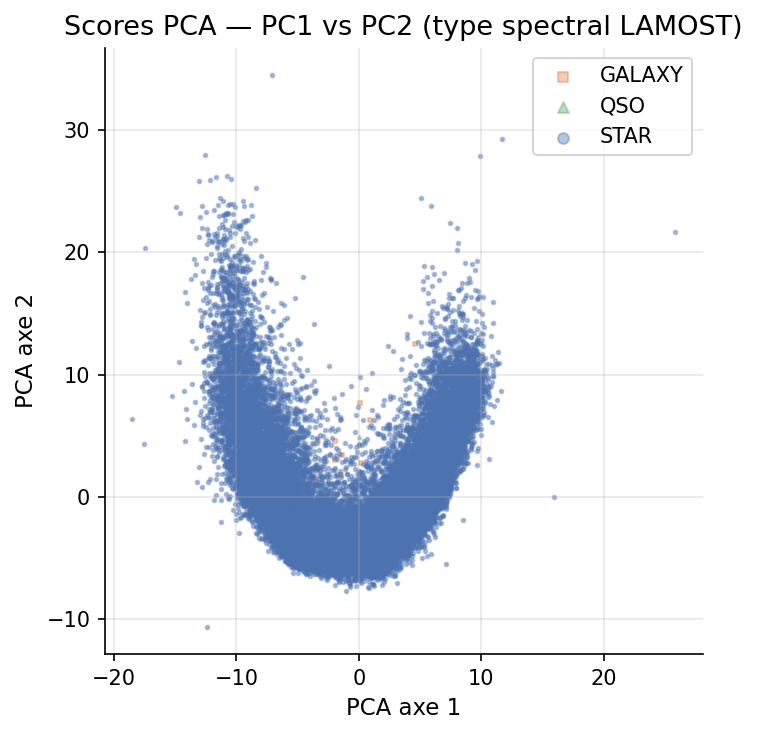

In [8]:
# PC1 vs PC2 — coloré par type spectral (toutes classes)
fig, ax = viz.plot_embedding(
    scores[:, :2],
    y=y,
    title="Scores PCA — PC1 vs PC2 (type spectral LAMOST)",
    method="PCA",
    s=3, alpha=0.4,
    save_path=FIGURES_DIR / "pca_scores_classes.png",
)
plt.show()

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_scores_grid.png


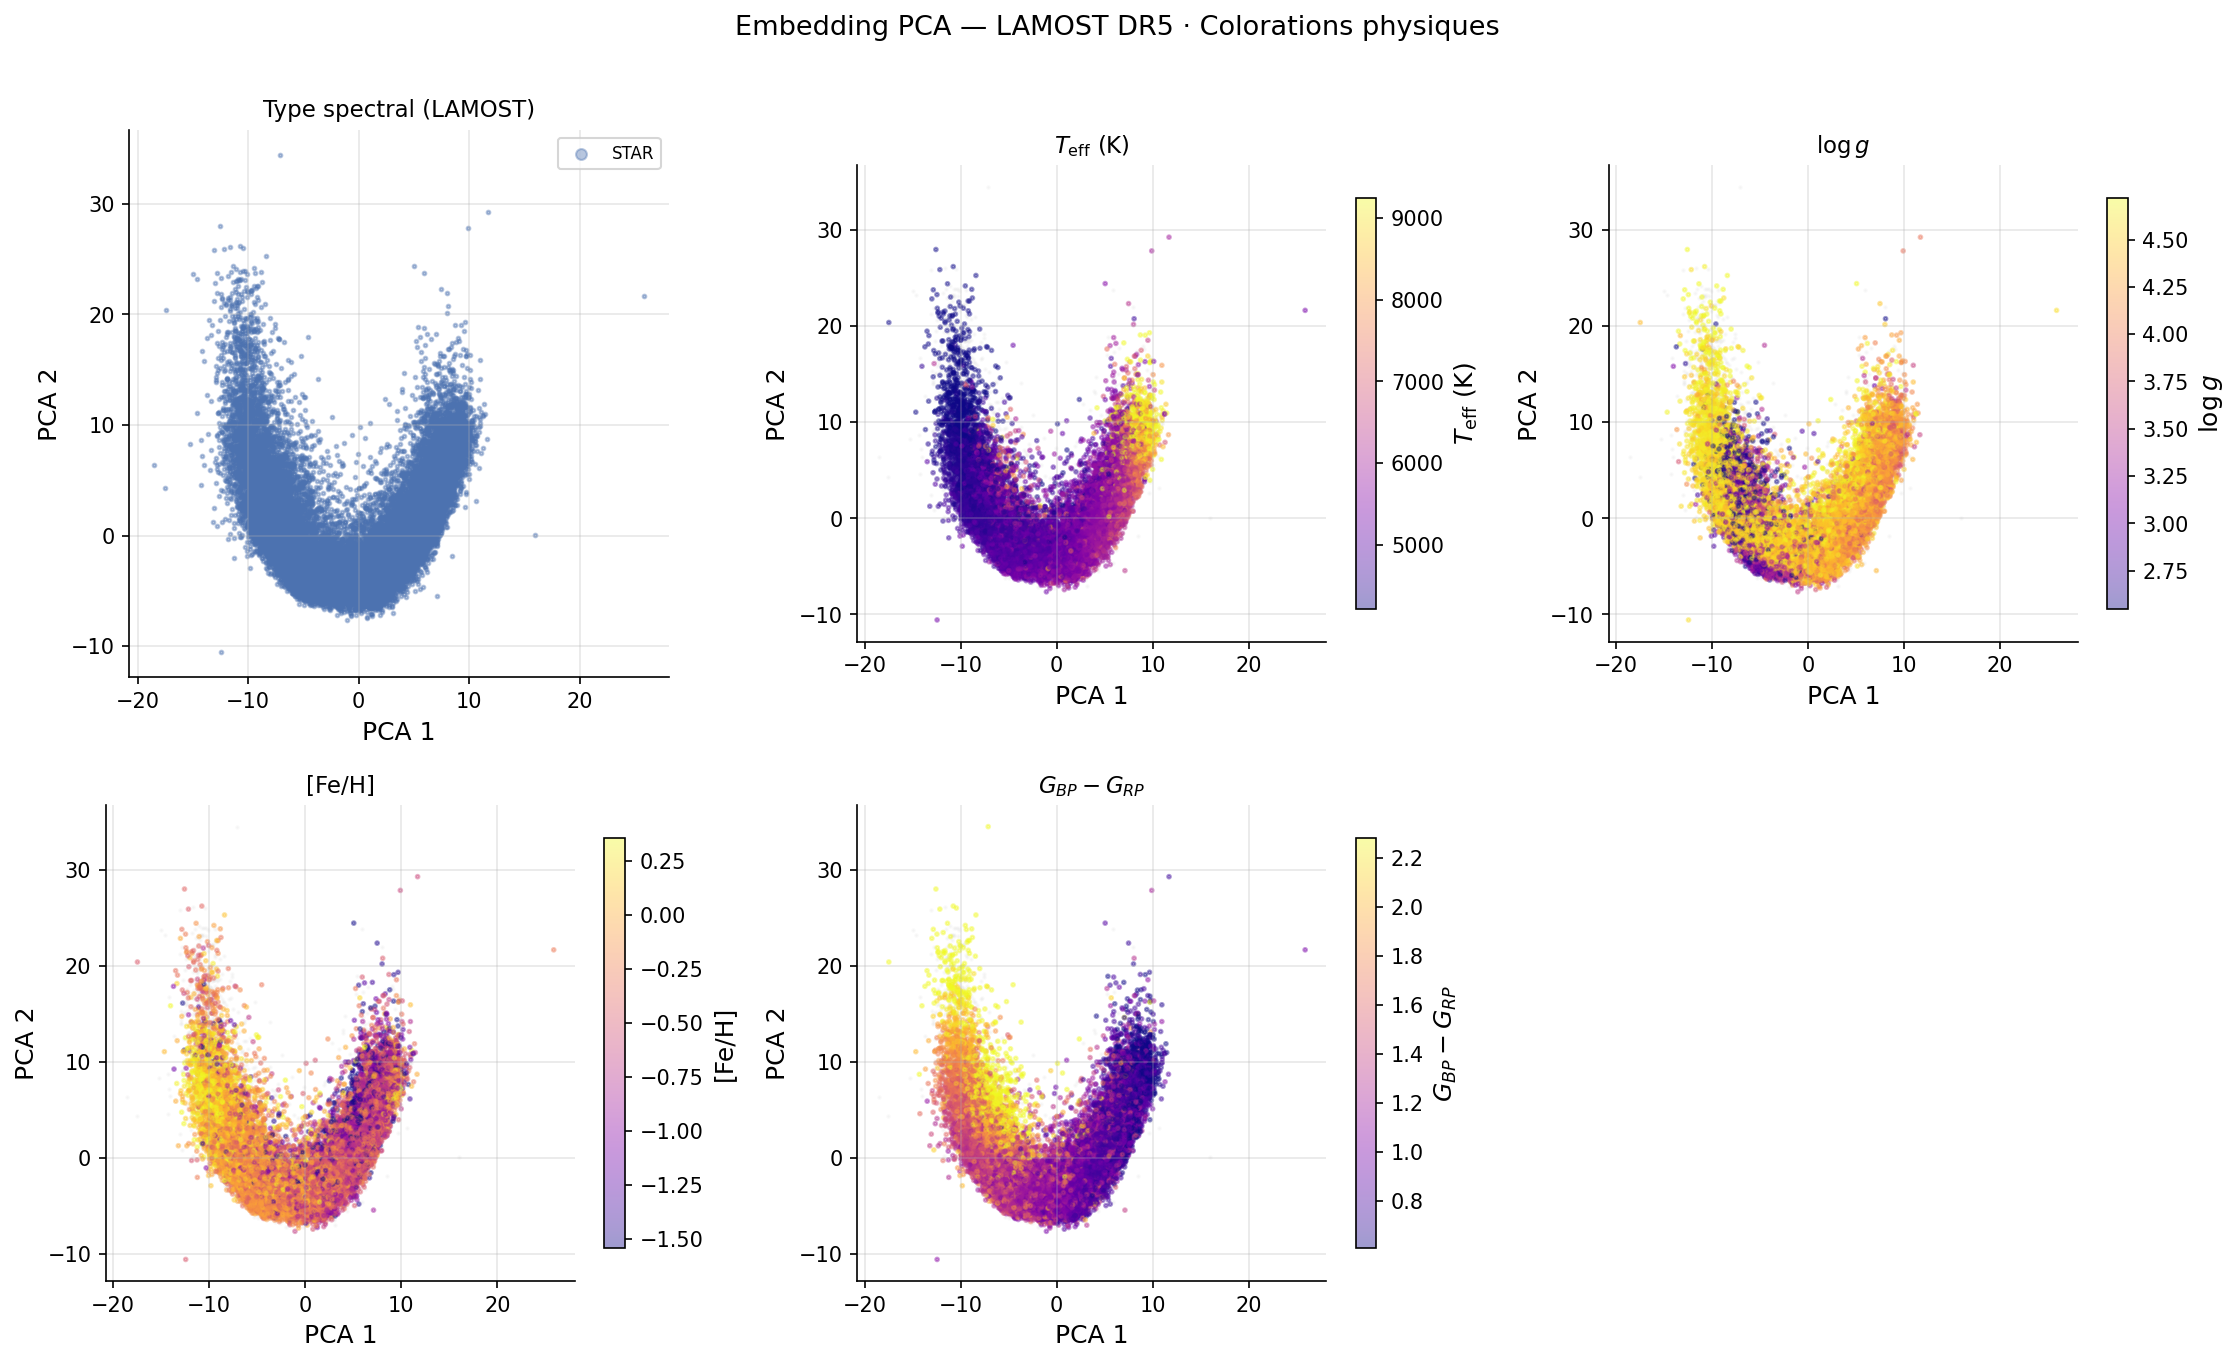

In [9]:
# Grille multi-coloration — étoiles uniquement (params Gaia disponibles)
mask_star = y == "STAR"

fig, axes = viz.plot_embedding_grid(
    scores[mask_star, :2],
    y=y[mask_star],
    meta=meta[mask_star].reset_index(drop=True),
    method="PCA",
    params=["teff_gspphot", "logg_gspphot", "mh_gspphot", "bp_rp"],
    s=3, alpha=0.4,
    save_path=FIGURES_DIR / "pca_scores_grid.png",
)
plt.show()

## 7 · Séparation des classes dans l'espace PCA

In [10]:
sep_df = pca.class_separation(X, y, n_pcs=5)
print("Statistiques de séparation par classe et par PC :")
print(sep_df.round(3).to_string())

Statistiques de séparation par classe et par PC :
                n   mean    std  median    q25    q75
classe PC                                            
GALAXY PC1     54 -1.535  3.726  -2.071 -4.572  0.710
       PC2     54  1.153  3.531   0.936 -1.421  2.978
       PC3     54  0.177  3.163   0.610 -1.352  1.663
       PC4     54  2.579  3.259   2.760  0.580  4.927
       PC5     54 -1.254  5.010  -0.250 -4.169  1.387
QSO    PC1      4  0.411  3.070   0.001 -0.879  1.291
       PC2      4  4.344  1.469   4.827  4.038  5.133
       PC3      4 -0.975  2.734  -1.200 -2.195  0.019
       PC4      4  3.358  6.806   2.108 -1.601  7.066
       PC5      4 -4.768  4.088  -6.189 -7.729 -3.228
STAR   PC1  42862  0.002  5.507   1.111 -4.707  4.547
       PC2  42862 -0.002  4.639  -1.065 -3.608  2.436
       PC3  42862 -0.000  2.976  -0.032 -2.018  2.056
       PC4  42862 -0.004  2.549  -0.246 -1.674  1.423
       PC5  42862  0.002  2.439   0.063 -1.219  1.153


## 8 · Erreur de reconstruction

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_reconstruction_error.png


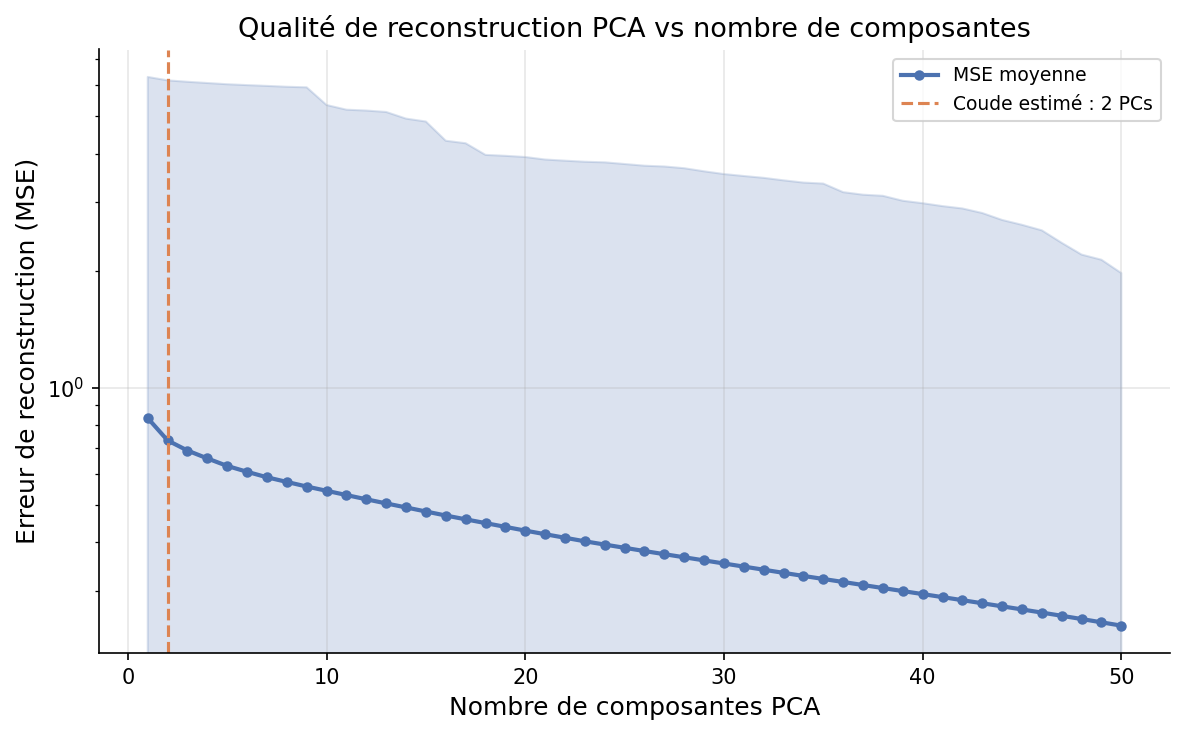

In [11]:
recon_df = pca.reconstruction_error_vs_n(
    X,
    n_range=list(range(1, 51)),
)

fig, ax = viz.plot_reconstruction_error(
    recon_df,
    save_path=FIGURES_DIR / "pca_reconstruction_error.png",
)
plt.show()

## 9 · PCA sur spectres bruts (eigen-spectres)

In [12]:
from dimred.data_loader import SpectralMatrixLoader
from sklearn.preprocessing import StandardScaler
from astropy.io import fits
import glob

spec_loader = SpectralMatrixLoader(
    fits_dir=Path(paths["RAW_DATA_DIR"]),
    catalog_path=CATALOG_PATH,
    n_jobs=8,
    random_state=RANDOM_STATE,
)

fits_dir = Path(paths["RAW_DATA_DIR"])
sample_files = list(fits_dir.rglob("*.fits*"))[:3]
print(f"Fichiers trouvés dans RAW_DATA_DIR : {len(list(fits_dir.rglob('*.fits*')))}")

for f in sample_files:
    print(f"\n--- {f.name} ---")
    try:
        with fits.open(f) as hdul:
            print(f"  HDU list : {[h.name for h in hdul]}")
            print(f"  Data shape : {hdul[0].data.shape if hdul[0].data is not None else 'None'}")
            header = hdul[0].header
            print(f"  COEFF0 : {header.get('COEFF0', 'ABSENT')}")
            print(f"  COEFF1 : {header.get('COEFF1', 'ABSENT')}")
            if hdul[0].data is not None:
                flux = hdul[0].data[0] if hdul[0].data.ndim > 1 else hdul[0].data
                print(f"  Flux range : [{flux.min():.2f}, {flux.max():.2f}]")
                print(f"  NaN count  : {np.isnan(flux).sum()}/{len(flux)}")
    except Exception as e:
        print(f"  ERREUR : {e}")

X_spec, y_spec, meta_spec = spec_loader.load(
    n_spectra=10_000,   # Sous-ensemble pour exploration rapide
    snr_min=10,
    normalize=True,
)

print(f"Matrice spectrale : {X_spec.shape}")
print(f"Grille λ : {spec_loader.wl_grid[0]:.0f} – {spec_loader.wl_grid[-1]:.0f} Å  ({len(spec_loader.wl_grid)} pixels)")

Fichiers trouvés dans RAW_DATA_DIR : 362065

--- spec-55916-B5591606_sp01-001.fits.gz ---
  HDU list : ['Flux']
  Data shape : (5, 3909)
  COEFF0 : 3.5682
  COEFF1 : 0.0001
  Flux range : [-347.64, 1647.06]
  NaN count  : 0/3909

--- spec-55916-B5591606_sp01-002.fits.gz ---
  HDU list : ['Flux']
  Data shape : (5, 3909)
  COEFF0 : 3.5682
  COEFF1 : 0.0001
  Flux range : [-272.17, 405.77]
  NaN count  : 0/3909

--- spec-55916-B5591606_sp01-003.fits.gz ---
  HDU list : ['Flux']
  Data shape : (5, 3909)
  COEFF0 : 3.5682
  COEFF1 : 0.0001
  Flux range : [-14.95, 1121.56]
  NaN count  : 0/3909


INFO | dimred.data_loader | Construction de l'index FITS dans C:\Users\alexb\Documents\Projets\AstroSpectro\data\raw...
INFO | dimred.data_loader | Index FITS construit : 362065 fichiers trouvés
INFO | dimred.data_loader | Chargement de 10000 spectres FITS (10000 résolus, 8 jobs)...
INFO | dimred.data_loader | Matrice spectrale prête : (10000, 3921)


Matrice spectrale : (10000, 3921)
Grille λ : 3690 – 9100 Å  (3921 pixels)


INFO | dimred.pca_analyzer | PCA ajustée : 50 composantes, 99.18% variance expliquée (cumulative)
INFO | dimred.pca_analyzer | 95% variance → 5 composantes (sur 50)


Variance expliquée (50 PCs) : 99.2%


INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\pca_spectra_variance_explained.png


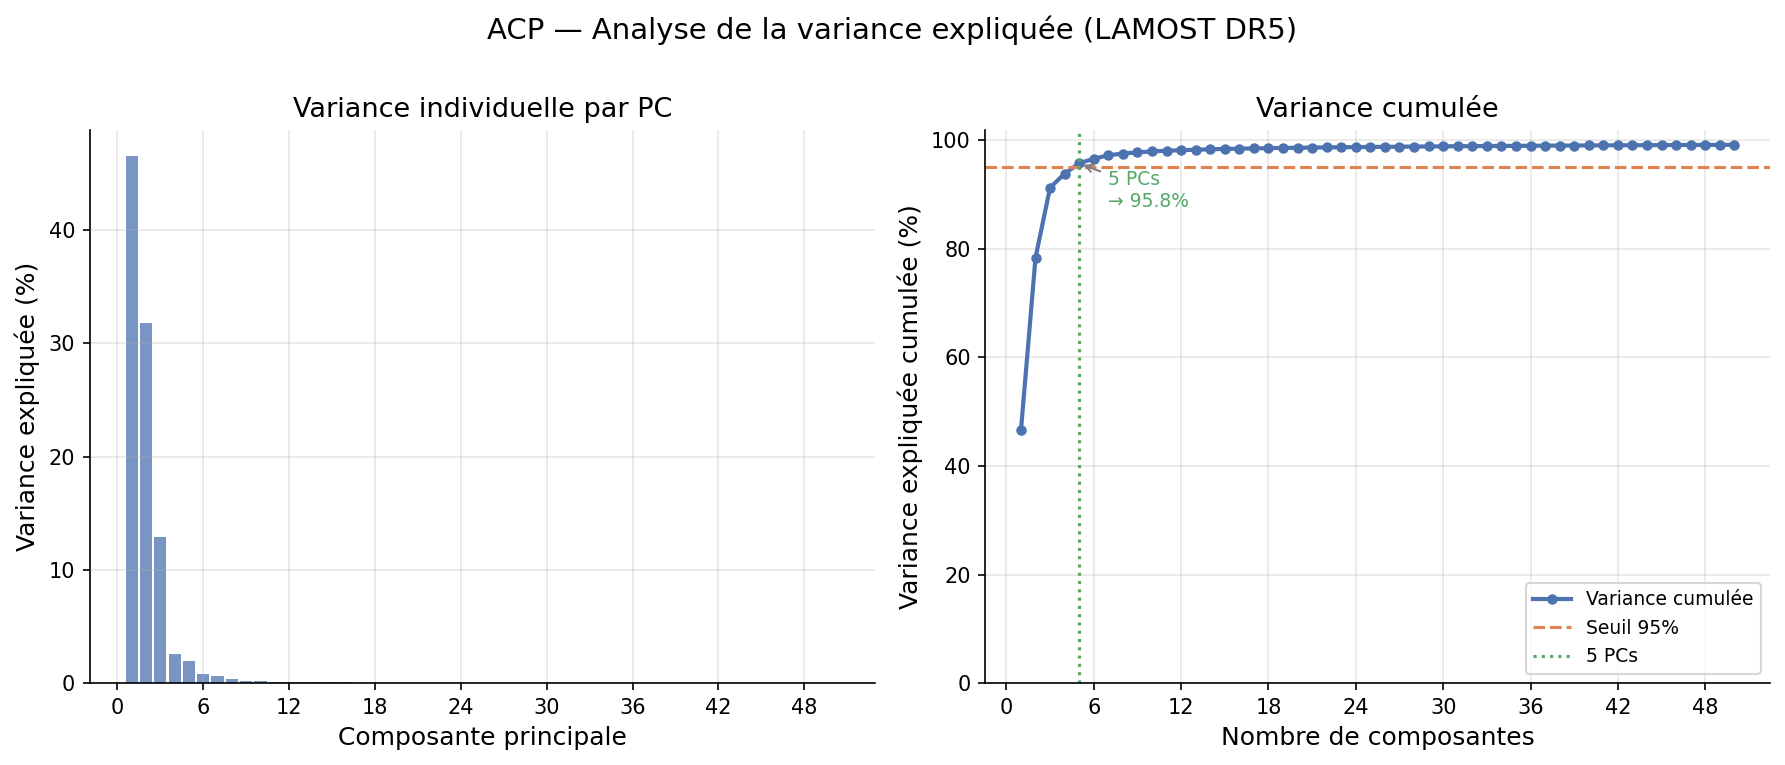

In [13]:
scaler_spec = StandardScaler()
X_spec_scaled = scaler_spec.fit_transform(X_spec)

pca_spec = PCAAnalyzer(n_components=50, random_state=RANDOM_STATE)
scores_spec = pca_spec.fit_transform(
    X_spec_scaled,
    feature_names=[f"λ{wl:.0f}" for wl in spec_loader.wl_grid],
)

print(f"Variance expliquée (50 PCs) : {pca_spec.cumulative_variance[-1]*100:.1f}%")

fig, axes = viz.plot_variance_explained(
    pca_spec, threshold=0.95,
    save_path=FIGURES_DIR / "pca_spectra_variance_explained.png",
)
plt.show()

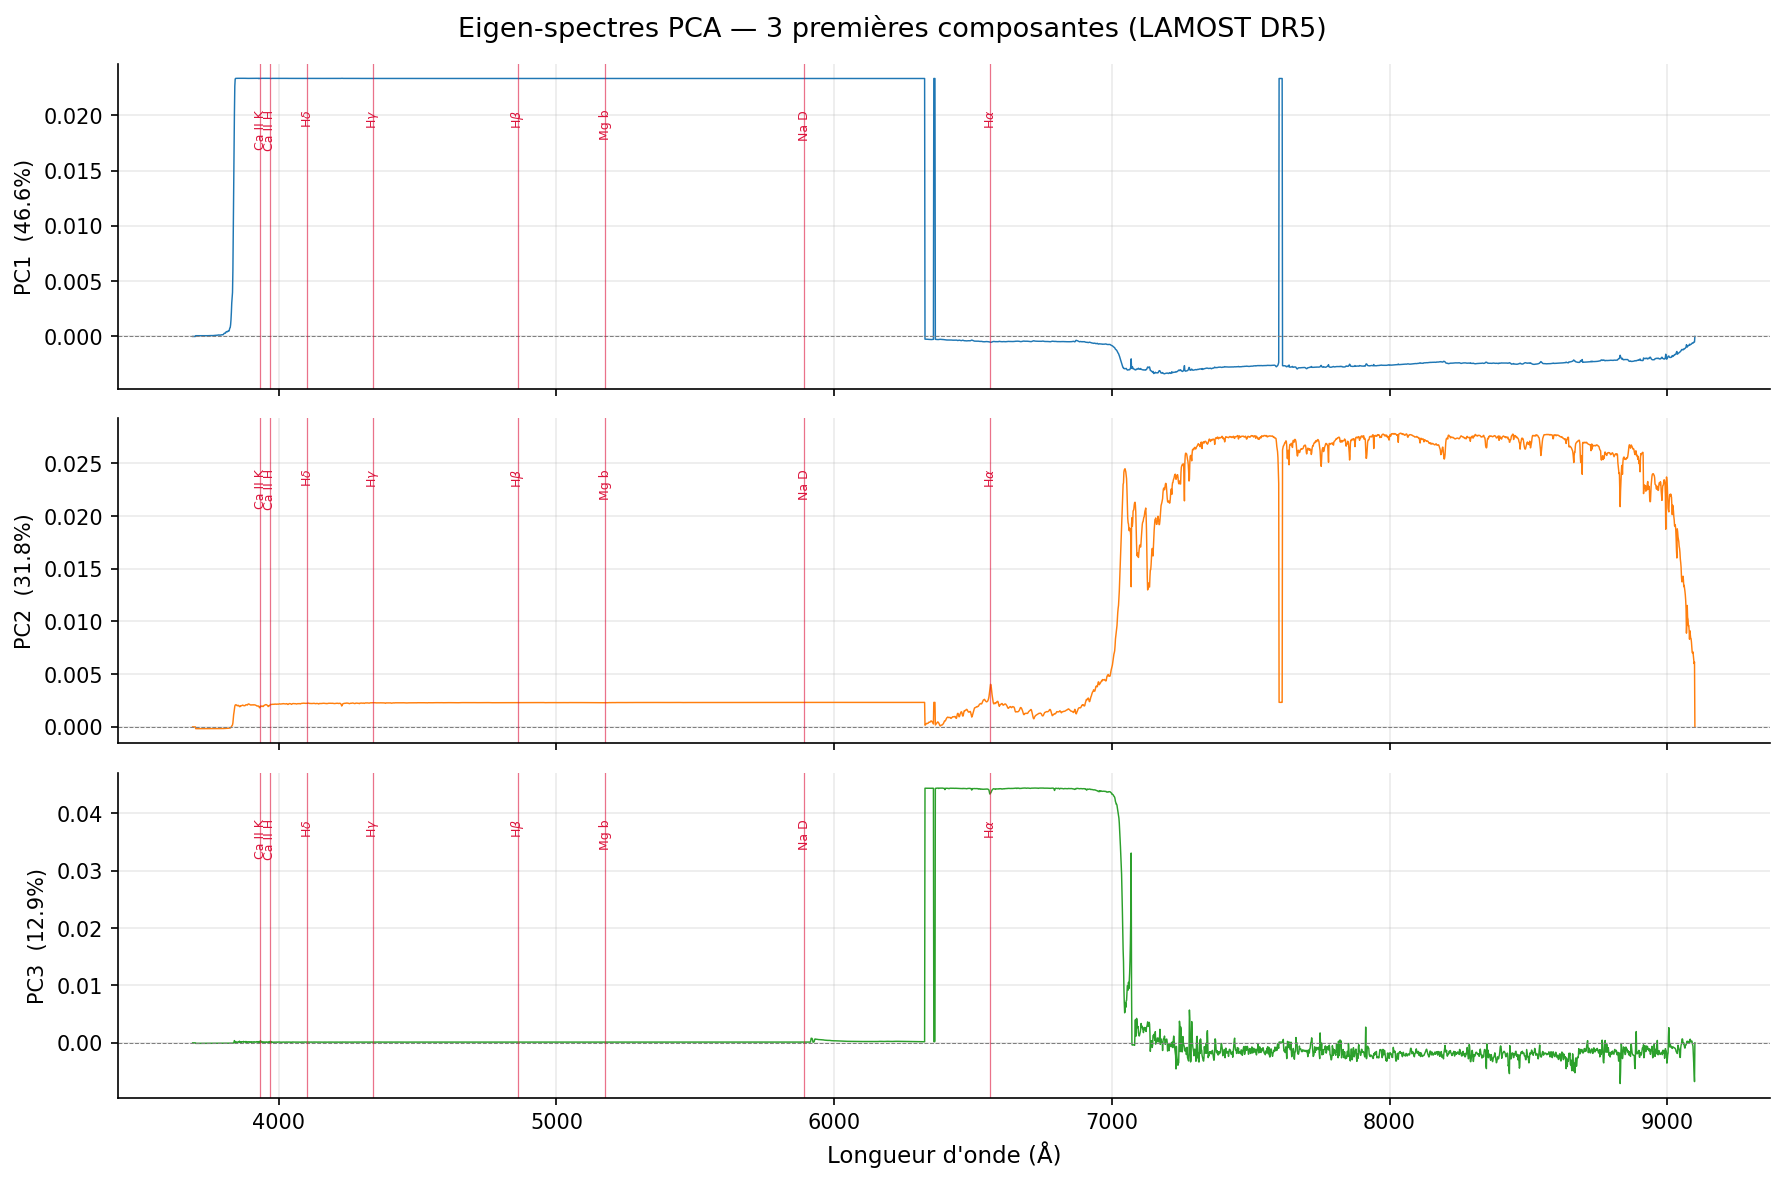

In [14]:
# Visualisation des eigen-spectres
RAIES = {
    r"H$\alpha$": 6563, r"H$\beta$": 4861, r"H$\gamma$": 4340, r"H$\delta$": 4102,
    "Ca II K": 3933, "Ca II H": 3968, "Mg b": 5175, "Na D": 5893,
}

fig, axes = plt.subplots(3, 1, figsize=(12, 8), dpi=150, sharex=True)
wl = spec_loader.wl_grid

for i, ax in enumerate(axes):
    vec = pca_spec.loadings[i]
    var_pct = pca_spec.explained_variance_ratio[i] * 100
    ax.plot(wl, vec, lw=0.7, color=f"C{i}")
    ax.axhline(0, color="gray", lw=0.5, ls="--")
    ax.set_ylabel(f"PC{i+1}  ({var_pct:.1f}%)", fontsize=10)
    ax.grid(True, alpha=0.25)
    ymax = np.abs(vec).max()
    for nom, lam in RAIES.items():
        if wl.min() < lam < wl.max():
            ax.axvline(lam, color="crimson", lw=0.6, alpha=0.6)
            ax.text(lam, ymax * 0.88, nom, rotation=90, fontsize=6,
                    color="crimson", ha="center", va="top")

axes[-1].set_xlabel("Longueur d'onde (Å)", fontsize=11)
fig.suptitle("Eigen-spectres PCA — 3 premières composantes (LAMOST DR5)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pca_eigenspectra.png", bbox_inches="tight", dpi=150)
plt.show()

## 10 · Diagramme HR coloré par coordonnée PCA

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\hr_diagram_pca_pc1.png


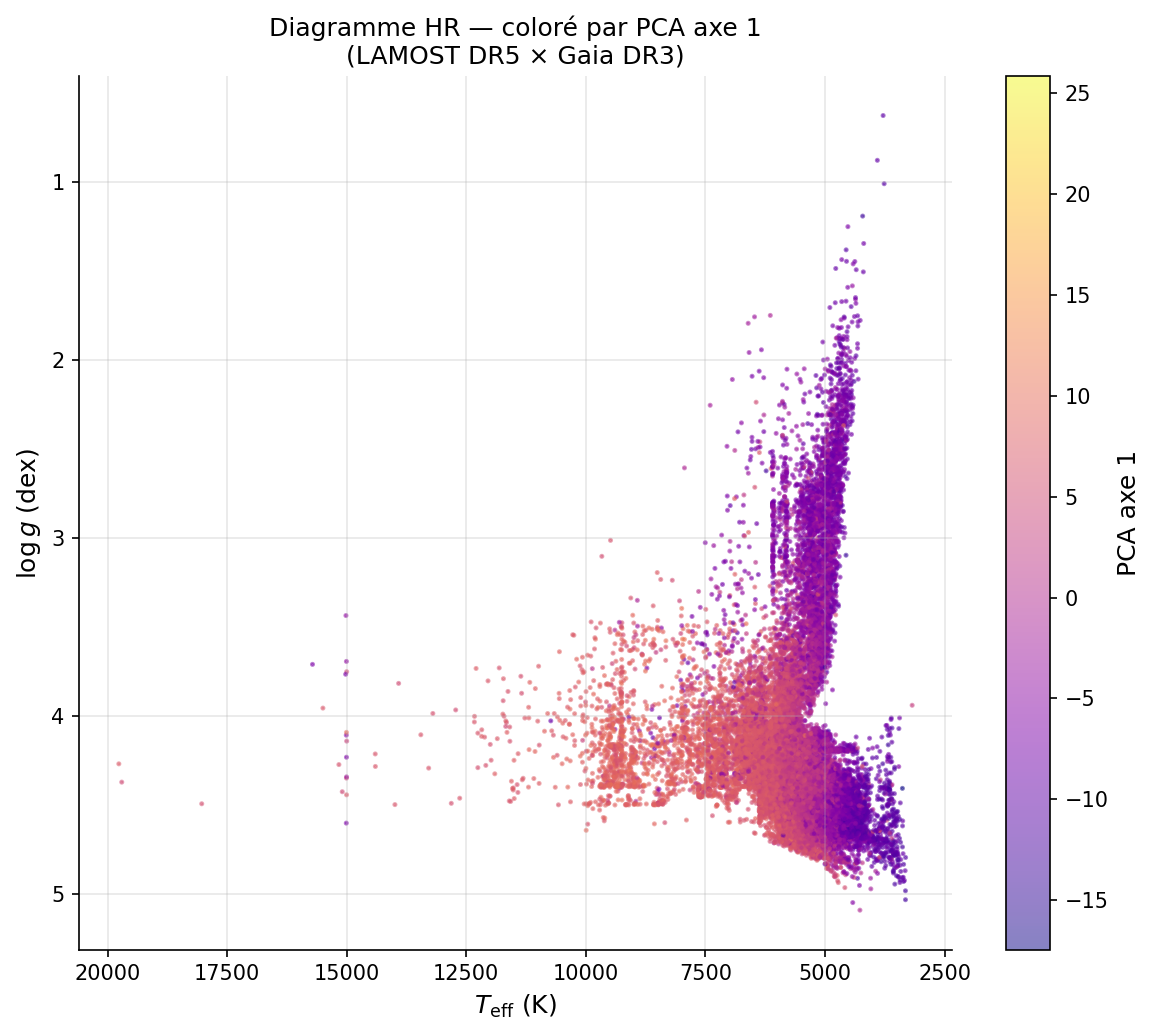

INFO | dimred.dimred_visualizer | Figure sauvegardée : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\hr_diagram_pca_pc2.png


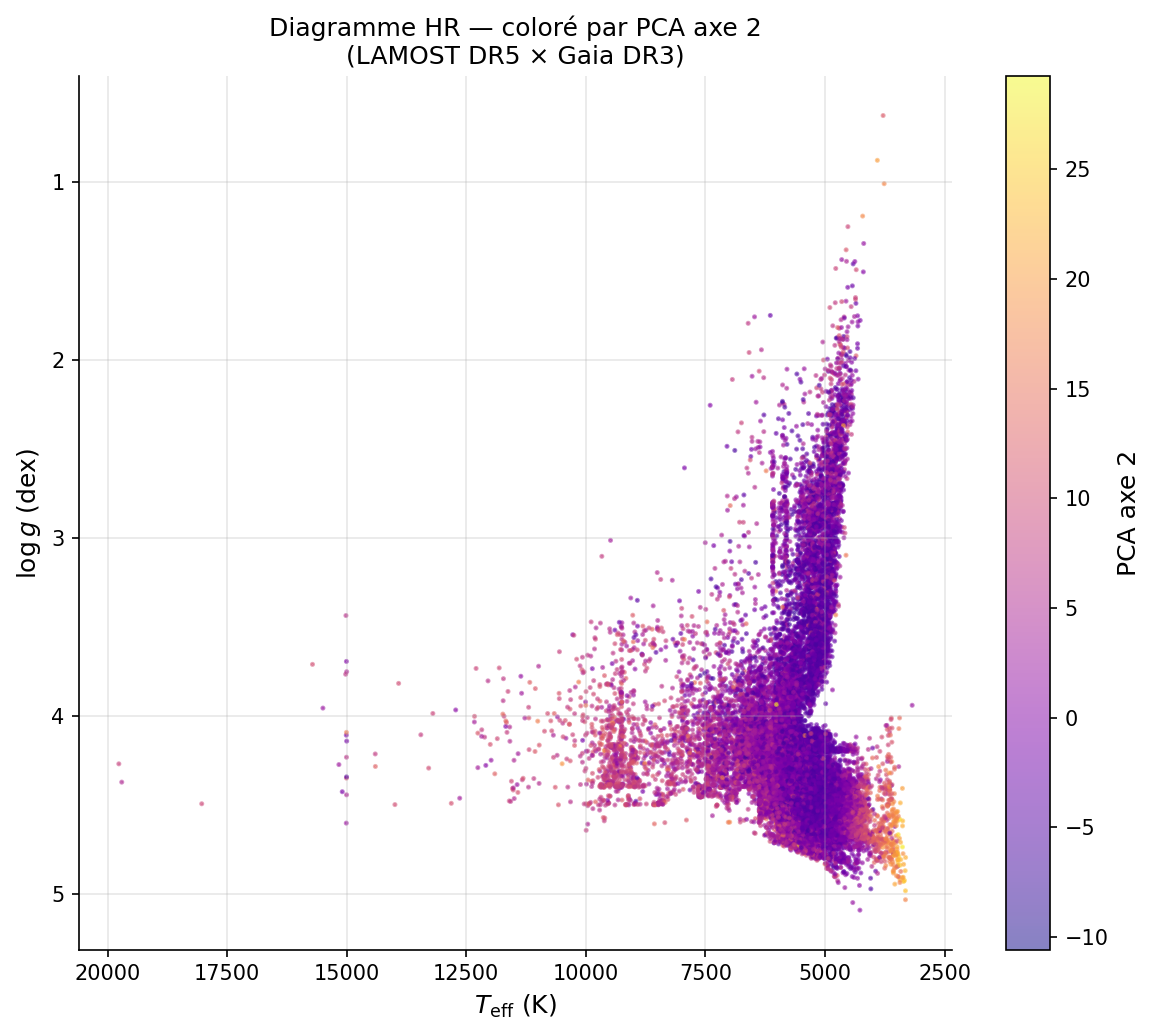

In [15]:
fig, ax = viz.plot_hr_diagram_embedding(
    meta=meta, Z=scores, component=0, method="PCA",
    save_path=FIGURES_DIR / "hr_diagram_pca_pc1.png",
)
plt.show()

fig, ax = viz.plot_hr_diagram_embedding(
    meta=meta, Z=scores, component=1, method="PCA",
    save_path=FIGURES_DIR / "hr_diagram_pca_pc2.png",
)
plt.show()

## 11 · Sauvegarde des scores → notebook 02

In [16]:
import joblib

n_keep      = pca.n_components_for_variance(0.95)
n_keep_spec = pca_spec.n_components_for_variance(0.95)

output = {
    "scores":               scores,
    "scores_95pct":         scores[:, :n_keep],
    "y":                    y,
    "meta":                 meta,
    "feature_names":        feature_names,
    "pca_variance_summary": pca.variance_summary(),
    "n_components_95pct":   n_keep,
    "scores_spec":          scores_spec,
    "scores_spec_95pct":    scores_spec[:, :n_keep_spec],
    "y_spec":               y_spec,
    "meta_spec":            meta_spec,
    "n_keep_spec":          n_keep_spec,
    "features_stem":        FEATURES_PATH.stem,
}

save_path = Path(paths["REPORTS_DIR"]) / "phy3500_pca_output.joblib"
joblib.dump(output, save_path)

print(f"Scores PCA sauvegardés → {save_path}")
print(f"  Features  (95% var)  : {scores[:, :n_keep].shape}  ({n_keep} PCs)")
print(f"  Spectres  (95% var)  : {scores_spec[:, :n_keep_spec].shape}  ({n_keep_spec} PCs)")

INFO | dimred.pca_analyzer | 95% variance → 51 composantes (sur 50)
INFO | dimred.pca_analyzer | 95% variance → 5 composantes (sur 50)


Scores PCA sauvegardés → C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\phy3500_pca_output.joblib
  Features  (95% var)  : (42920, 50)  (51 PCs)
  Spectres  (95% var)  : (10000, 5)  (5 PCs)


---

## Résumé des résultats

| Analyse | Résultat clé |
|---------|-------------|
| Variance 95% (features) | X PCs |
| Variance 95% (spectres bruts) | Y PCs |
| PC1 dominée par | À compléter |
| PC2 dominée par | À compléter |
| Corrélation PC1 – T_eff | ρ = ? |
| Corrélation PC1 – [Fe/H] | ρ = ? |

**→ Notebook suivant** : `02_umap_tsne.ipynb`